In [18]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [19]:
df = pd.read_csv("customer_segmentation.csv")

In [20]:
df.shape

(2240, 29)

In [21]:
df.isna().sum() #check data empty value jaise income  mein 24 hai

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64

In [22]:
df.dropna(inplace = True) #drop all empty values

In [ ]:
df.isna().sum()  

In [25]:
df["Education"].value_counts()

Education
Graduation    1116
PhD            481
Master         365
2n Cycle       200
Basic           54
Name: count, dtype: int64

In [27]:
df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"], dayfirst = True)  #convert object to number

In [29]:
df["Age"] = 2025 - df["Year_Birth"]  #ye age wala data nahi hai isiliye create ker rehe hai

In [30]:
df["Total_Children"] = df["Kidhome"] + df["Teenhome"]

In [31]:
spend_cols = ["MntWines", "MntFruits", "MntMeatProducts", "MntFishProducts", "MntSweetProducts", "MntGoldProds"]

In [32]:
df["Total_Spending"] = df[spend_cols].sum(axis = 1)  #total spending ko add kiya hai

In [33]:
df["Customer_Since"] = (pd.Timestamp("today") - df["Dt_Customer"]).dt.days

In [34]:
df["Customer_Since"]

0       4983
1       4433
2       4632
3       4459
4       4481
        ... 
2235    4701
2236    4339
2237    4475
2238    4476
2239    4942
Name: Customer_Since, Length: 2216, dtype: int64

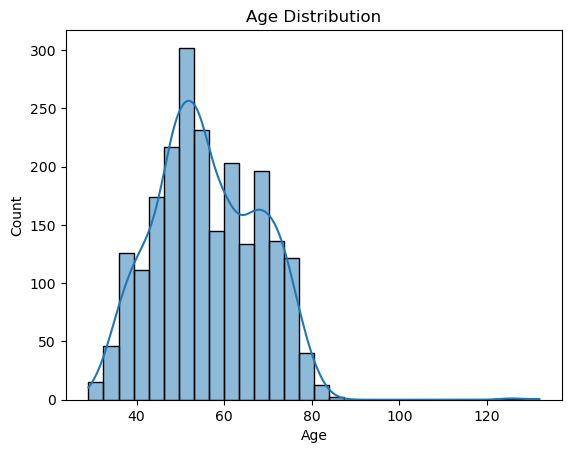

In [35]:
sns.histplot(df["Age"], bins=30, kde=True)
plt.title("Age Distribution")
plt.show()

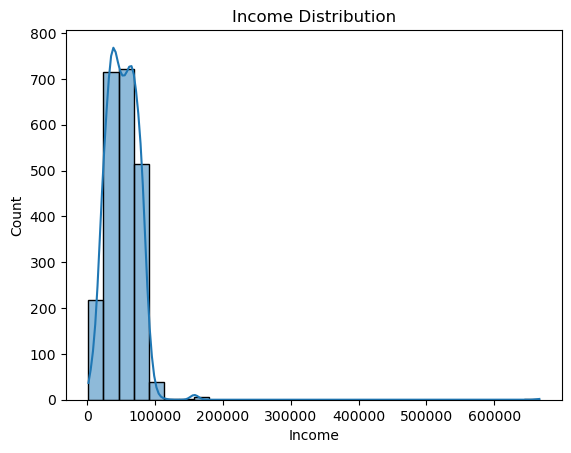

In [36]:
sns.histplot(df["Income"], bins = 30, kde = True)
plt.title("Income Distribution")
plt.show()

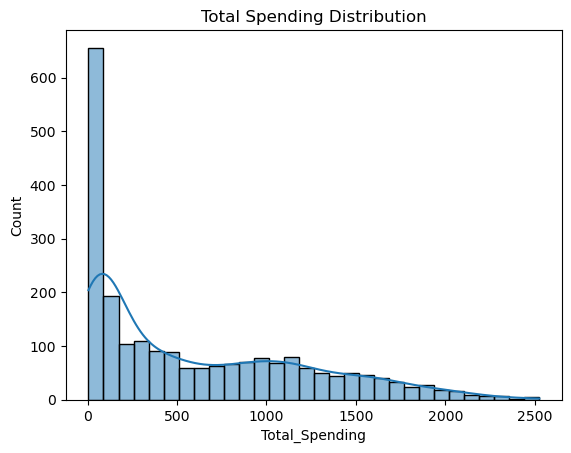

In [37]:
sns.histplot(df["Total_Spending"], bins = 30, kde = True)
plt.title("Total Spending Distribution")
plt.show()

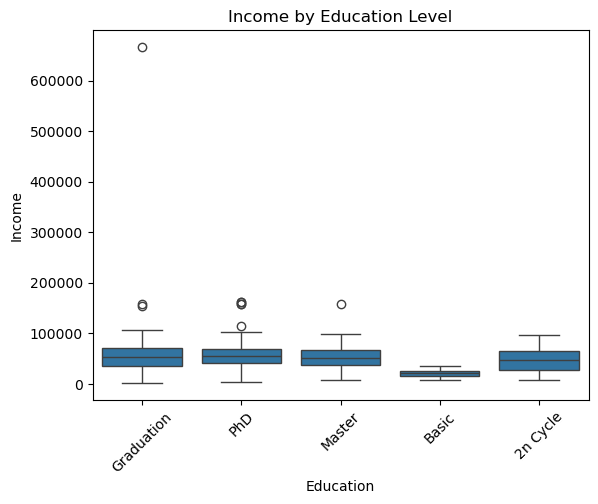

In [38]:
sns.boxplot(
    x = "Education",
    y ="Income",
    data=df
)
plt.xticks(rotation = 45)
plt.title("Income by Education Level")
plt.show()

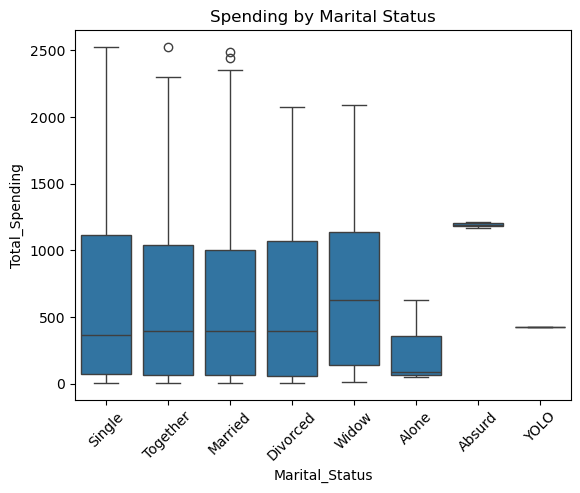

In [39]:
sns.boxplot(
    x = "Marital_Status",
    y = "Total_Spending",
    data = df
)
plt.xticks(rotation = 45)
plt.title("Spending by Marital Status")
plt.show()

In [40]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response',
       'Age', 'Total_Children', 'Total_Spending', 'Customer_Since'],
      dtype='object')

In [45]:
corr = df[["Income", "Age", "Recency", "Total_Spending", "NumWebPurchases", "NumStorePurchases"]].corr()

In [46]:
corr

,Income,Age,Recency,Total_Spending,NumWebPurchases,NumStorePurchases
Income,1.000000,0.161791,-0.003970,0.667576,0.387878,0.529362
Age,0.161791,1.000000,0.016295,0.113487,0.153051,0.127891
Recency,-0.003970,0.016295,1.000000,0.020066,-0.005641,-0.000434
Total_Spending,0.667576,0.113487,0.020066,1.000000,0.528973,0.675181
NumWebPurchases,0.387878,0.153051,-0.005641,0.528973,1.000000,0.516240
NumStorePurchases,0.529362,0.127891,-0.000434,0.675181,0.516240,1.000000


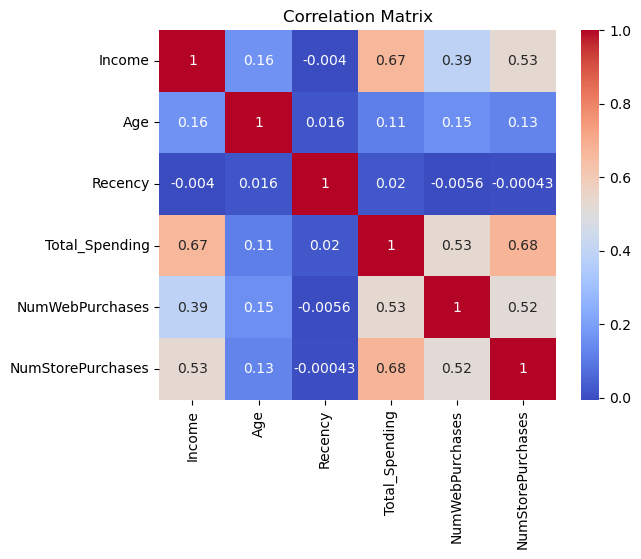

In [49]:
sns.heatmap(
    corr,
    annot = True,
    cmap = "coolwarm"
)
plt.title("Correlation Matrix")
plt.show()

In [50]:
pivot_income = df.pivot_table(
    values = "Income",
    index = "Education",
    columns = "Marital_Status",
    aggfunc = "mean"
)

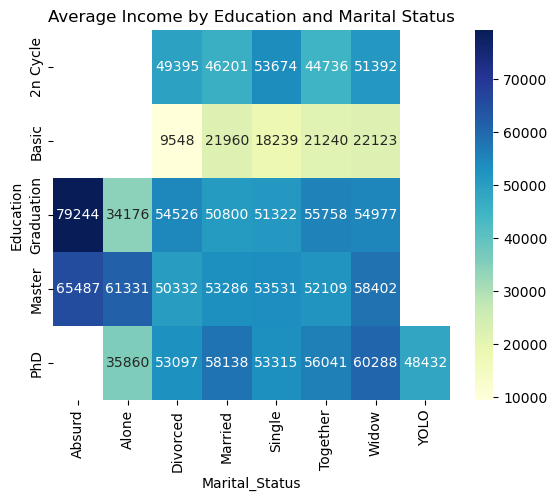

In [52]:
sns.heatmap(pivot_income, annot = True, fmt = ".0f", cmap="YlGnBu")
plt.title("Average Income by Education and Marital Status")
plt.show()

In [53]:
group1 = df.groupby("Education")["Total_Spending"].mean().sort_values(ascending = False)

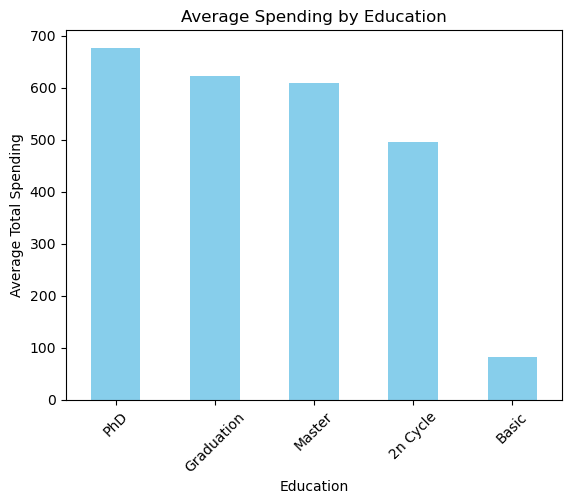

In [56]:
group1.plot(
    kind = "bar", color = "skyblue"
)
plt.title("Average Spending by Education")
plt.ylabel("Average Total Spending")
plt.xticks(rotation = 45)
plt.show()

In [58]:
df["AcceptedAny"] = df[["AcceptedCmp1", "AcceptedCmp2", "AcceptedCmp3", "AcceptedCmp4", "AcceptedCmp5", "Response"]].sum(axis = 1)

In [60]:
df["AcceptedAny"].unique()

array([1, 0])

In [59]:
df["AcceptedAny"] =df["AcceptedAny"].apply(lambda x: 1 if x>0 else 0)

In [62]:
group2 = df.groupby("Marital_Status")["AcceptedAny"].mean().sort_values(ascending=False)

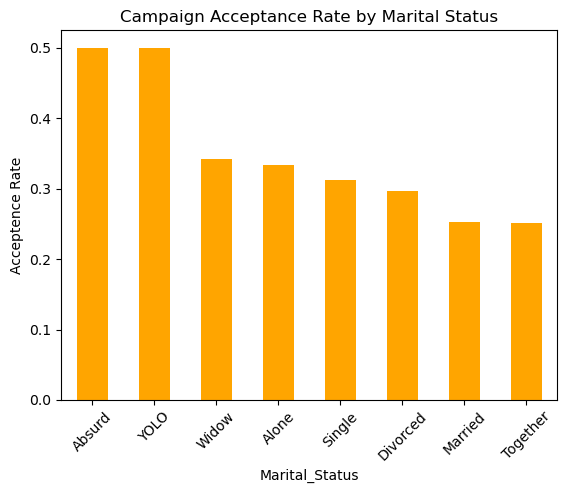

In [63]:
group2.plot(kind="bar", color="orange")
plt.title("Campaign Acceptance Rate by Marital Status")
plt.ylabel("Acceptence Rate")
plt.xticks(rotation = 45)
plt.show()

In [64]:
bins = [18, 30, 40, 50, 60, 70, 90]

In [65]:
labels = ["18-29", "30-39", "40-49", "50-59", "60-69", "70+"]

In [66]:
df["AgeGroup"] = pd.cut(df["Age"], bins = bins, labels = labels)

In [67]:
df["AgeGroup"]

0       60-69
1         70+
2       50-59
3       40-49
4       40-49
        ...  
2235    50-59
2236      70+
2237    40-49
2238    60-69
2239      70+
Name: AgeGroup, Length: 2216, dtype: category
Categories (6, object): ['18-29' < '30-39' < '40-49' < '50-59' < '60-69' < '70+']

In [68]:
group3 = df.groupby("AgeGroup")["Income"].mean()

C:\Users\Rohit\AppData\Local\Temp\ipykernel_31408\1140876350.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group3 = df.groupby("AgeGroup")["Income"].mean()


In [69]:
group3

AgeGroup
18-29    46658.000000
30-39    46283.028302
40-49    49224.877034
50-59    50812.913303
60-69    56200.827887
70+      58944.316294
Name: Income, dtype: float64

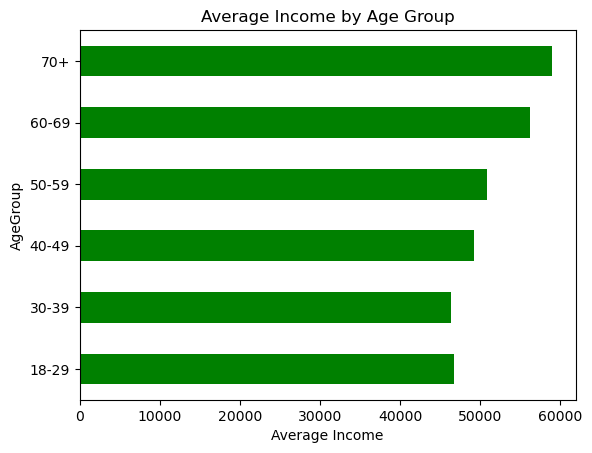

In [70]:
group3.plot(kind="barh", color="green")
plt.title("Average Income by Age Group")
plt.xlabel("Average Income")
plt.show()

In [71]:
features = ["Age", "Income", "Total_Spending", "NumWebPurchases", "NumStorePurchases", "NumWebVisitsMonth", "Recency"]

In [72]:
X = df[features].copy()

In [73]:
X

,Age,Income,Total_Spending,NumWebPurchases,NumStorePurchases,NumWebVisitsMonth,Recency
0,68,58138.0,1617,8,4,7,58
1,71,46344.0,27,1,2,5,38
2,60,71613.0,776,8,10,4,26
3,41,26646.0,53,2,4,6,26
4,44,58293.0,422,5,6,5,94
...,...,...,...,...,...,...,...
2235,58,61223.0,1341,9,4,5,46
2236,79,64014.0,444,8,5,7,56
2237,44,56981.0,1241,2,13,6,91
2238,69,69245.0,843,6,10,3,8


In [74]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

In [75]:
X_scaled = scaler.fit_transform(X)

In [76]:
X_scaled

array([[ 0.98644293,  0.2340627 ,  1.67548812, ..., -0.55414289,
         0.69323197,  0.31053212],
       [ 1.23680074, -0.23455948, -0.96235832, ..., -1.16951781,
        -0.1315745 , -0.38050944],
       [ 0.31882209,  0.76947764,  0.28024985, ...,  1.29198186,
        -0.54397773, -0.79513438],
       ...,
       [-1.01641959,  0.18809052,  1.05169551, ...,  2.21504423,
         0.28082874,  1.4507507 ],
       [ 1.06989553,  0.67538765,  0.39140438, ...,  1.29198186,
        -0.95638097, -1.41707178],
       [ 1.23680074,  0.02470453, -0.7218    , ..., -0.55414289,
         0.69323197, -0.31140528]], shape=(2216, 7))

In [77]:
#apply k means and elbow method
from sklearn.cluster import KMeans

In [78]:
wcss = []

In [79]:
for i in range(2,10):
    kmeans = KMeans(n_clusters=i)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

In [80]:
wcss

[10218.648106906197,
 9007.786818672806,
 8159.030830397129,
 7729.500087057213,
 7132.011414626798,
 6728.862494313466,
 6172.966598692674,
 5913.604997708308]

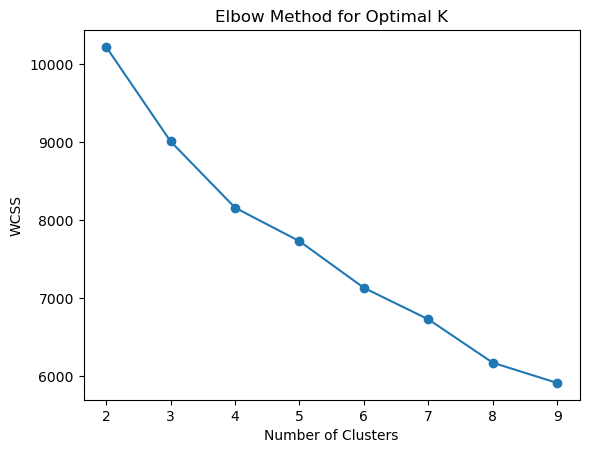

In [82]:
plt.plot(range(2,10),wcss,marker = "o")
plt.title("Elbow Method for Optimal K")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

In [85]:
kmeans = KMeans(n_clusters=6)
df["Cluster"] = kmeans.fit_predict(X_scaled)

In [86]:
df["Cluster"]

0       3
1       5
2       3
3       5
4       2
       ..
2235    3
2236    1
2237    0
2238    4
2239    1
Name: Cluster, Length: 2216, dtype: int32

In [88]:
cluster_summary = df.groupby("Cluster")[features].mean()

In [89]:
cluster_summary

,Age,Income,Total_Spending,NumWebPurchases,NumStorePurchases,NumWebVisitsMonth,Recency
Cluster,,,,,,,
0,46.158228,79028.674051,1323.300633,4.575949,8.572785,2.585443,46.917722
1,61.771242,54474.454248,594.137255,5.990196,6.424837,6.261438,25.405229
2,55.125483,36400.980695,128.691120,2.372587,3.438224,6.378378,75.793436
3,58.252708,62446.101083,1044.541516,8.314079,8.862816,6.158845,63.032491
4,69.858586,73799.343434,1173.572391,4.400673,8.239057,2.414141,54.505051
5,50.930279,32003.948207,81.193227,1.862550,2.982072,6.627490,26.101594


In [90]:
df["Cluster"].value_counts()

Cluster
2    518
5    502
0    316
1    306
4    297
3    277
Name: count, dtype: int64

In [91]:
#visualise cluster using PCA
from sklearn.decomposition import PCA

In [93]:
pca = PCA(n_components=2)
pca_data = pca.fit_transform(X_scaled)
df["PCA1"], df["PCA2"] = pca_data[:, 0], pca_data[:, 1]

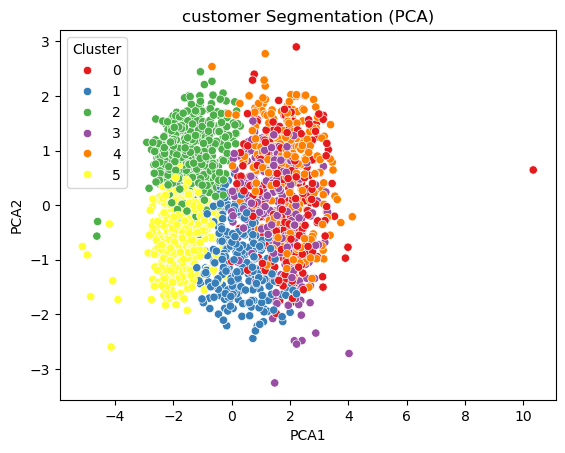

In [95]:
sns.scatterplot(
    x="PCA1",
    y="PCA2",
    hue="Cluster",
    data=df,
    palette="Set1"
)
plt.title("customer Segmentation (PCA)")
plt.show()

In [96]:
import joblib

joblib.dump(kmeans, "kmeans_model.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']